# Société Générale vs CAC 40: Price Performance and Risk Analysis

## Research Question

How did Société Générale (`GLE.PA`) perform relative to the CAC 40 (`^FCHI`) over the last five years in terms of price return, volatility, and drawdown?

## Objective

This project uses Python to compare the historical price performance and risk of Société Générale with the French equity-market benchmark.

## Scope

The analysis uses daily closing prices and focuses on total price return, CAGR, annualized volatility, maximum drawdown, and rolling volatility. It is an educational historical analysis, not investment advice.

In [36]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

In [37]:
from pathlib import Path

PROJECT_DIR = Path.home() / "socgen-price-risk-analysis"
FIGURES_DIR = PROJECT_DIR / "figures"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Figures will be saved to: {FIGURES_DIR.resolve()}")

Figures will be saved to: /Users/faraz/socgen-price-risk-analysis/figures


In [38]:
# Define the analysis period
START_DATE = "2021-09-23"
END_DATE = "2026-09-23"

# Download daily price data
socgen_raw = yf.download(
    "GLE.PA",
    start=START_DATE,
    end=END_DATE,
    auto_adjust=False,
    progress=False
)

cac40_raw = yf.download(
    "^FCHI",
    start=START_DATE,
    end=END_DATE,
    auto_adjust=False,
    progress=False
)

print("Société Générale data shape:", socgen_raw.shape)
print("CAC 40 data shape:", cac40_raw.shape)


Société Générale data shape: (1280, 6)
CAC 40 data shape: (1280, 6)


In [39]:
# Extract closing prices for a consistent price-performance comparison
socgen = socgen_raw["Close"].iloc[:, 0].rename("Société Générale")
cac40 = cac40_raw["Close"].iloc[:, 0].rename("CAC 40")

# Combine both price series into one clean table
prices = pd.concat([socgen, cac40], axis=1).dropna()

prices.head()

,Société Générale,CAC 40
Date,,
2021-09-23,26.045000,6701.979980
2021-09-24,26.334999,6638.459961
2021-09-27,27.170000,6650.910156
2021-09-28,26.535000,6506.500000
2021-09-29,27.115000,6560.799805


## Data Quality Check

The two price series are aligned by date. Rows with missing values are removed before calculating returns and risk metrics.

In [40]:
# Check the quality of the analysis dataset
print(f"Number of observations: {len(prices):,}")
print(f"Date range: {prices.index.min().date()} to {prices.index.max().date()}")

print("\nMissing values per column:")
print(prices.isna().sum())

Number of observations: 1,279
Date range: 2021-09-23 to 2026-09-21

Missing values per column:
Société Générale    0
CAC 40              0
dtype: int64


## Daily Returns

Daily returns measure the percentage change in closing prices from one trading day to the next.

In [41]:
# Calculate daily percentage returns
daily_returns = prices.pct_change(fill_method=None).dropna()

daily_returns.head()

,Société Générale,CAC 40
Date,,
2021-09-24,0.011135,-0.009478
2021-09-27,0.031707,0.001875
2021-09-28,-0.023371,-0.021713
2021-09-29,0.021858,0.008345
2021-09-30,0.002950,-0.006217


## Indexed Price Performance

Both series are rebased to 100 on the first trading day so that their relative price performance can be compared despite different price scales.

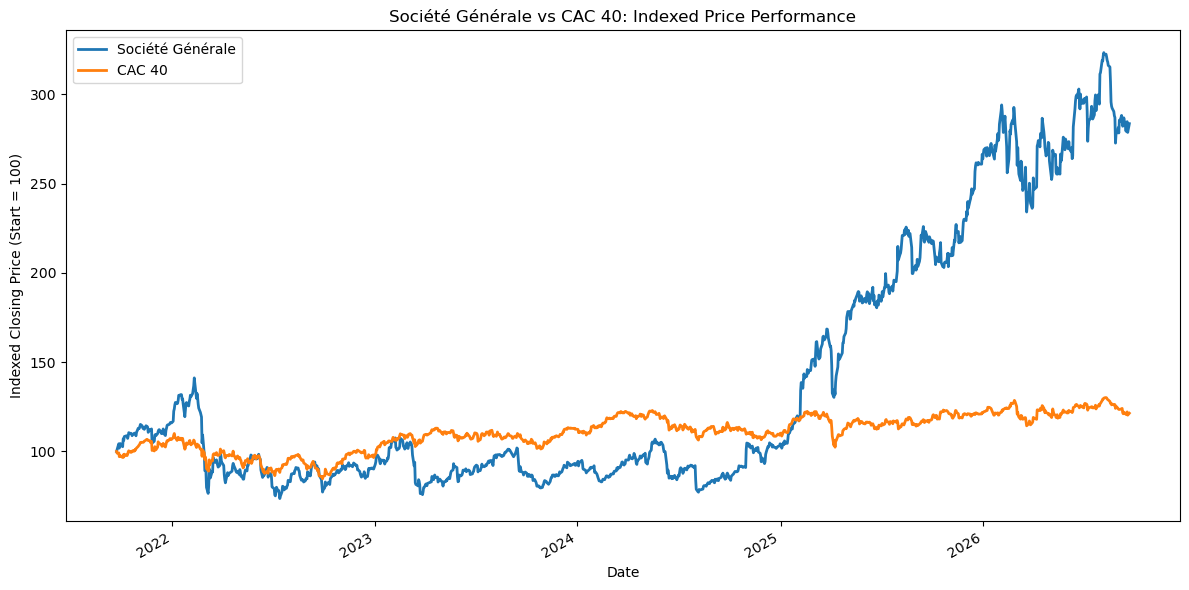

Saved: /Users/faraz/socgen-price-risk-analysis/figures/indexed_price_performance.png


In [42]:
# Rebase both price series to 100 on the first trading day
indexed_prices = prices.div(prices.iloc[0]).mul(100)

ax = indexed_prices.plot(figsize=(12, 6), linewidth=2)

ax.set_title("Société Générale vs CAC 40: Indexed Price Performance")
ax.set_xlabel("Date")
ax.set_ylabel("Indexed Closing Price (Start = 100)")
ax.legend(title="")

figure_path = FIGURES_DIR / "indexed_price_performance.png"

plt.tight_layout()
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {figure_path}")

## Performance and Risk Summary

This section compares total price return, compound annual growth rate (CAGR), and annualized volatility for Société Générale and the CAC 40.

In [43]:
# Calculate the exact length of the analysis period
years = (prices.index[-1] - prices.index[0]).days / 365.25

# Calculate total price return
total_return = (prices.iloc[-1] / prices.iloc[0] - 1) * 100

# Calculate compound annual growth rate
cagr = (
    (prices.iloc[-1] / prices.iloc[0]) ** (1 / years) - 1
) * 100

# Calculate annualized volatility from daily returns
annualized_volatility = (
    daily_returns.std() * (252 ** 0.5) * 100
)

# Create a summary table
summary = pd.DataFrame({
    "Total Price Return (%)": total_return,
    "CAGR (%)": cagr,
    "Annualized Volatility (%)": annualized_volatility
})

summary.round(2)

,Total Price Return (%),CAGR (%),Annualized Volatility (%)
Société Générale,183.62,23.21,34.43
CAC 40,21.44,3.97,16.33


## Drawdown Analysis

Drawdown measures the percentage decline from a previous peak. Maximum drawdown represents the worst peak-to-trough loss during the analysis period.

In [44]:
# Calculate drawdowns from previous price peaks
running_max = prices.cummax()
drawdown = prices.div(running_max).sub(1)

# Find the largest peak-to-trough decline
max_drawdown = drawdown.min() * 100

# Add maximum drawdown to the summary table
summary["Maximum Drawdown (%)"] = max_drawdown

summary.round(2)

,Total Price Return (%),CAGR (%),Annualized Volatility (%),Maximum Drawdown (%)
Société Générale,183.62,23.21,34.43,-47.86
CAC 40,21.44,3.97,16.33,-23.04


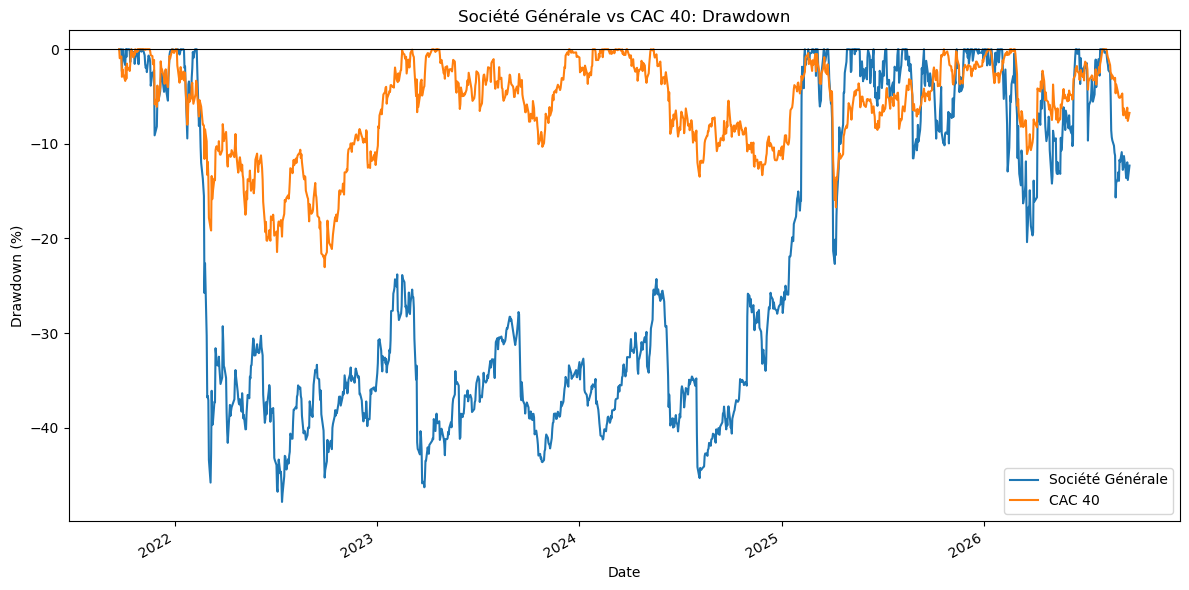

Saved: /Users/faraz/socgen-price-risk-analysis/figures/drawdown.png


In [45]:
# Plot drawdowns over time
drawdown_pct = drawdown * 100

ax = drawdown_pct.plot(figsize=(12, 6), linewidth=1.5)

ax.set_title("Société Générale vs CAC 40: Drawdown")
ax.set_xlabel("Date")
ax.set_ylabel("Drawdown (%)")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylim(drawdown_pct.min().min() - 2, 2)
ax.legend(title="")

figure_path = FIGURES_DIR / "drawdown.png"

plt.tight_layout()
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {figure_path}")

## Rolling Volatility

Rolling volatility shows how market risk changes over time, using a 30-trading-day window.

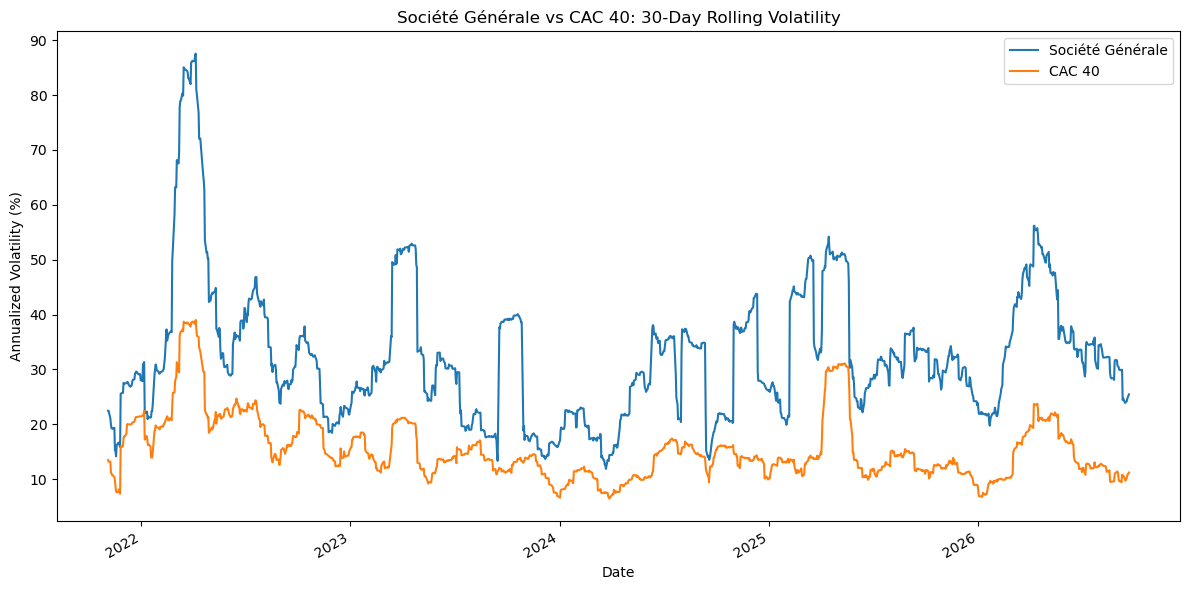

Saved: /Users/faraz/socgen-price-risk-analysis/figures/rolling_volatility.png


In [46]:
# Calculate 30-day rolling annualized volatility
rolling_volatility = (
    daily_returns
    .rolling(window=30)
    .std()
    * (252 ** 0.5)
    * 100
)

ax = rolling_volatility.plot(figsize=(12, 6), linewidth=1.5)

ax.set_title("Société Générale vs CAC 40: 30-Day Rolling Volatility")
ax.set_xlabel("Date")
ax.set_ylabel("Annualized Volatility (%)")
ax.legend(title="")

figure_path = FIGURES_DIR / "rolling_volatility.png"

plt.tight_layout()
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {figure_path}")

## Key Findings

- From 23 September 2021 to 21 September 2026, Société Générale generated a total price return of **183.62%**, compared with **21.44%** for the CAC 40.
- Société Générale achieved a CAGR of **23.21%**, while the CAC 40 achieved a CAGR of **3.97%**.
- Société Générale had higher annualized volatility (**34.43%**) than the CAC 40 (**16.33%**).
- The maximum drawdown of Société Générale was **-47.86%**, compared with **-23.04%** for the CAC 40.
- The rolling-volatility analysis shows that Société Générale experienced more frequent and larger short-term risk spikes, particularly during early 2022.
- Overall, Société Générale outperformed the CAC 40 in historical price performance, but this higher return was accompanied by substantially higher volatility and drawdown risk.

## Limitations

- This project uses historical daily market data downloaded from Yahoo Finance through the `yfinance` library.
- The analysis compares closing-price performance and does not include dividends, transaction costs, taxes, or currency effects.
- The CAC 40 is used as a market benchmark and is not directly investable.
- Results depend on the selected time period and may change if the underlying data is revised.
- Historical performance does not predict future returns. This project is for educational purposes and does not provide investment advice.

In [47]:
# Create the list of Python packages needed to run this project
requirements = """yfinance
pandas
matplotlib
"""

requirements_path = PROJECT_DIR / "requirements.txt"
requirements_path.write_text(requirements, encoding="utf-8")

print(f"Created: {requirements_path}")

Created: /Users/faraz/socgen-price-risk-analysis/requirements.txt


In [48]:
# Create rules for files that should not be uploaded to GitHub
gitignore = """.ipynb_checkpoints/
__pycache__/
*.pyc
.DS_Store
.env
"""

gitignore_path = PROJECT_DIR / ".gitignore"
gitignore_path.write_text(gitignore, encoding="utf-8")

print(f"Created: {gitignore_path}")

Created: /Users/faraz/socgen-price-risk-analysis/.gitignore


In [49]:
# Create the GitHub README file for the project
readme = """# Société Générale vs CAC 40: Price and Risk Analysis

## Overview

This project compares the historical price performance and risk profile of Société Générale with the CAC 40 using Python.

## Research Question

How did Société Générale (`GLE.PA`) perform relative to the CAC 40 (`^FCHI`) between 23 September 2021 and 21 September 2026 in terms of price return, CAGR, annualized volatility, maximum drawdown, and 30-day rolling volatility?

## Data

- **Source:** Yahoo Finance, accessed with `yfinance`
- **Frequency:** Daily
- **Société Générale:** `GLE.PA`
- **Benchmark:** `^FCHI` (CAC 40 price index)
- **Clean common observations:** 1,279
- **Price field used:** `Close`

This is a price-performance analysis. It does not include dividends, transaction costs, taxes, or currency effects.

## Methodology

1. Download daily closing-price data with `yfinance`.
2. Align both series by trading date and remove missing observations.
3. Calculate daily percentage returns.
4. Rebase both price series to 100 on the first trading day.
5. Calculate total price return, CAGR, and annualized volatility.
6. Measure maximum drawdown from previous price peaks.
7. Calculate 30-day rolling annualized volatility.

## Key Results

| Metric | Société Générale | CAC 40 |
| --- | ---: | ---: |
| Total Price Return | 183.62% | 21.44% |
| CAGR | 23.21% | 3.97% |
| Annualized Volatility | 34.43% | 16.33% |
| Maximum Drawdown | -47.86% | -23.04% |

Société Générale delivered substantially higher price performance over the period, but with materially higher volatility and a deeper maximum drawdown than the CAC 40.

## Visualizations

### Indexed Price Performance

![Indexed price performance](figures/indexed_price_performance.png)

### Drawdown

![Drawdown](figures/drawdown.png)

### 30-Day Rolling Volatility

![Rolling volatility](figures/rolling_volatility.png)

## Project Structure

```text
socgen-price-risk-analysis/
├── socgen_price_risk_analysis.ipynb
├── figures/
│   ├── indexed_price_performance.png
│   ├── drawdown.png
│   └── rolling_volatility.png
├── README.md
├── requirements.txt
└── .gitignore

pip install -r requirements.txt
jupyter notebook socgen_price_risk_analysis.ipynb

Limitations
- Historical market data may be revised by the data provider.
- Results use closing prices rather than total-return series.
- The analysis excludes dividends, transaction costs, taxes, and currency effects.
- This project is for educational purposes and is not investment advice.
Skills Demonstrated
- Python and Jupyter Notebook
- Financial data collection with yfinance
- Data cleaning with pandas
- Return and risk measurement
- CAGR, volatility, and drawdown analysis
- Financial data visualization with matplotlib
- Reproducible project organization for GitHub
  """
readme_path = PROJECT_DIR / "README.md"
readme_path.write_text(readme, encoding="utf-8")
print(f"Created: {readme_path}")

Created: /Users/faraz/socgen-price-risk-analysis/README.md
